# Event Sequence Visualization Case Study (Python / Sequenzo)

This notebook is the Python companion to `event_sequences_visual_comparison_traminer.qmd` in the same folder. We reproduce four **event-sequence** visualization patterns used in TraMineR / TraMineRextras.

In this tutorial, we first look at the two datasets side by side (what each row/column means, and how they relate). Only afterwards do we build `SequenceData`, convert to event sequences, and plot.

The four visualization families:

1. `plot_event_parallel_coordinates` — parallel coordinates for event sequences  
2. `plot_subsequence_frequencies` — bar chart of frequent subsequences  
3. `plot_subsequence_group_contrasts` — group contrasts on subsequences  
4. `plot_event_dynamics` — survival / hazard-style curves  

Comments in code cells are deliberately explicit for teaching.


In [1]:
# Standard plotting stack
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display

# Sequenzo imports for state and event sequence analysis
from sequenzo.define_sequence_data import SequenceData
from sequenzo.event_sequences import (
    EventSequenceData,
    find_frequent_subsequences,
    compare_groups,
    plot_event_parallel_coordinates,
    plot_subsequence_frequencies,
    plot_subsequence_group_contrasts,
    plot_event_dynamics,
)

plt.style.use("default")
plt.rcParams["figure.dpi"] = 120


## Part A — Inspect the two CSV files (before any modeling)

TraMineR ships two representations of the **same substantive example** ("activity calendars", `actcal`). We exported both to CSV under `sequenzo/datasets/`:

| File | Abbreviation | Role |
|------|--------------|------|
| `actcal.csv` | **STS** (state sequence) | Wide table: **one row per person**, **one column per time point** |
| `actcal_tse.csv` | **TSE** (time-stamped events) | Long table: **many rows per person**, each row is **one event at one time** |

If you are comfortable with STS but new to event sequences, spending five minutes here prevents confusion later (especially why `plot_event_parallel_coordinates` in this notebook does **not** read `actcal.tse` directly).


### `actcal.csv` — state sequences (wide / STS)

- **`id`**: person identifier (matches `id` in `actcal_tse.csv`).  
- **`jan00` … `dec00`**: labour-force **state** in each month of 2000 (coded `A`–`D` in this export; in publications these often map to ordered activity levels).  
- Other columns (`sex`, `region00`, …): covariates — useful for grouping (we use `sex` later).

**Interpretation:** each cell tells you *which state someone occupies in that month*, not *a narrative event label* like “Stop” or “Start”.


In [2]:
PATH_CAL = "../../sequenzo/datasets/actcal.csv"
MONTH_COLS = [
    "jan00", "feb00", "mar00", "apr00", "may00", "jun00",
    "jul00", "aug00", "sep00", "oct00", "nov00", "dec00",
]

peek_cal = pd.read_csv(PATH_CAL, nrows=8)
print("Preview: id, sex, and the 12 monthly state columns.\n")
display(peek_cal[["id", "sex"] + MONTH_COLS])


Preview: id, sex, and the 12 monthly state columns.


,id,sex,jan00,feb00,mar00,apr00,may00,jun00,jul00,aug00,sep00,oct00,nov00,dec00
0,1,woman,B,B,B,B,B,B,B,B,B,B,B,B
1,2,woman,D,D,D,D,A,A,A,A,A,A,A,D
2,3,woman,B,B,B,B,B,B,B,B,B,B,B,B
3,4,woman,C,C,C,C,C,C,C,C,C,B,B,B
4,5,man,A,A,A,A,A,A,A,A,A,A,A,A
5,6,woman,D,B,B,B,B,B,B,B,B,B,B,B
6,7,woman,D,D,D,D,D,D,D,D,D,D,D,D
7,8,man,A,A,A,A,A,A,A,A,A,A,A,A


The preview above is only the **first eight persons**. Person `id == 2`, for example, stays in state `D` for several months, then switches into `A`, holds `A`, and returns to `D` by December — that story lives in **twelve letters across one row**, not in separate labeled events.


### `actcal_tse.csv` — timestamped events (long / TSE)

Columns:

- **`id`**: same person key as in `actcal.csv`.  
- **`time`**: time of the event (here, months within the window used in the TraMineR example; `0` is a common origin).  
- **`event`**: **text label** of something that happens at that clock time (`PartTime`, `NoActivity`, `Start`, `FullTime`, `Stop`, …).

**Important:** one person appears on **multiple rows**. Two rows with the **same** `(id, time)` mean **two events occur together** at that instant (e.g. both `Start` and `FullTime` at `time == 4` for person 2 in the excerpt below).

**Reading the first lines of the file (compare with `sequenzo/datasets/actcal_tse.csv`):**

- `id == 1`, `time == 0`, `event == "PartTime"` → one event logged at the origin for person 1.  
- `id == 2`, `time == 0`, `NoActivity` → person 2 starts in "no activity" at month 0.  
- Two successive rows with **`id == 2`, `time == 4`** (`Start`, then `FullTime`) → **two distinct labels occur at the same clock time** (compound episode onset).  
- `id == 2`, `time == 11`, `Stop` → a later transition months afterward.

Below we display an abbreviated slice with `pandas` so you can see the same pattern interactively.


In [3]:
PATH_TSE = "../../sequenzo/datasets/actcal_tse.csv"

peek_tse = pd.read_csv(PATH_TSE, nrows=14)
print("First rows of the long event table:\n")
display(peek_tse)

print("\n--- Same excerpt restricted to id == 2 (matches the head of the CSV you saw in the R tutorial) ---")
display(peek_tse[peek_tse["id"] == 2])


First rows of the long event table:


,id,time,event
0,1,0,PartTime
1,2,0,NoActivity
2,2,4,Start
3,2,4,FullTime
4,2,11,Stop
5,3,0,PartTime
6,4,0,LowPartTime
7,4,9,Increase
8,4,9,PartTime
9,5,0,FullTime



--- Same excerpt restricted to id == 2 (matches the head of the CSV you saw in the R tutorial) ---


,id,time,event
1,2,0,NoActivity
2,2,4,Start
3,2,4,FullTime
4,2,11,Stop


### How the two CSVs correspond

- **They are not two sheets of the same join key beyond `id`.** You do **not** merge them row-for-row to build `plot_event_parallel_coordinates`.
- **STS (`actcal.csv`)**: convenient when your raw data are panel states (`D,D,D,...,A,A,...`).  
- **TSE (`actcal_tse.csv`)**: convenient when your raw data are dated institutional events ("started full-time", "stopped", ...).

For **one analysis** you choose **one representation** (or convert deliberately):

| Goal | Typical input |
|------|----------------|
| Parallel-coordinates plot from monthly states + custom event names | STS + a **`transition` matrix** passed to `EventSequenceData.from_state_sequences` (same idea as R `seqecreate(actcal.seq, event_representation = transition)`) |
| Survival / hazard plots driven by real event times in the long file | TSE columns `id`, `time`, `event` -> `EventSequenceData.from_tse(data=...)` (same idea as R `seqecreate(actcal.tse)`) |

So when the R document runs `head(actcal.tse)`, it shows **native long-format events**. When it builds `actcal.eseq` for **`plot_event_parallel_coordinates`**, it uses **`seqecreate(actcal.seq, event_representation = transition)`** — labels such as `NoActivity` on that object come from the **matrix cells**, not from scanning `actcal.tse`.


### What we do next in *this* notebook

1. **Parts B-F** follow the **STS + custom transition matrix** route (build object -> mine -> `plot_event_parallel_coordinates` -> barplots -> chi-square plots), aligning with the R tutorial sections around blocks 2-6 of `event_sequences_visual_comparison_traminer.qmd`.  
2. **`plot_event_dynamics` at the end** still uses the **`eseq` built from STS** here (time axis = positions derived from the state grid). That demonstrates the plotting API. To mirror R section 7 **exactly**, build a second `eseq` from `actcal_tse.csv` and pass it to `plot_event_dynamics`.

Run the next cells in order.


## Part B — Build event sequences from the STS file + transition matrix

We now load a subset of rows from **`actcal.csv`** (400 sequences — edit `nrows` if you want the full file).

Steps:

1. Build **`SequenceData`** on the twelve monthly columns (`jan00`–`dec00`).  
2. Provide the **same $4 \times 4$ event-label matrix** as in the R Quarto file (`transition <- seqetm(...)` then manual edits).  
3. Call **`EventSequenceData.from_state_sequences(..., event_representation=transition)`** — analogous to `seqecreate(actcal.seq, event_representation = transition)`.

If you instead passed **`event_representation="transition"`** without a custom matrix, event names would default to symbols like `A` and `A>B`; the matrix is what introduces narrative strings (`Stop`, `FullTime`, …).


In [4]:
csv_path = "../../sequenzo/datasets/actcal.csv"
df = pd.read_csv(csv_path, nrows=400)

sequence_cols = [
    "jan00", "feb00", "mar00", "apr00", "may00", "jun00",
    "jul00", "aug00", "sep00", "oct00", "nov00", "dec00",
]

seqdata = SequenceData(
    data=df,
    time=sequence_cols,
    id_col="id",
    states=["A", "B", "C", "D"],
)

transition = np.empty((4, 4), dtype=object)
transition[0, :] = [
    "FullTime",
    "Decrease,PartTime",
    "Decrease,LowPartTime",
    "Stop",
]
transition[1, :] = [
    "Increase,FullTime",
    "PartTime",
    "Decrease,LowPartTime",
    "Stop",
]
transition[2, :] = [
    "Increase,FullTime",
    "Increase,PartTime",
    "LowPartTime",
    "Stop",
]
transition[3, :] = [
    "Start,FullTime",
    "Start,PartTime",
    "Start,LowPartTime",
    "NoActivity",
]

eseq = EventSequenceData.from_state_sequences(seqdata=seqdata, event_representation=transition)

print(eseq)
print("Number of event types:", len(eseq.dictionary))
print("First 15 event labels:", eseq.dictionary[:15])



[>] SequenceData initialized successfully! Here's a summary:
[>] Number of sequences: 400
[>] Number of time points: 12
[>] Min/Max sequence length: 12 / 12
[>] States: ['A', 'B', 'C', 'D']
[>] Labels: ['A', 'B', 'C', 'D']
[>] Weights: Not provided
EventSequenceList(n=400, events=12)
Number of event types: 12
First 15 event labels: ['FullTime', 'Decrease,PartTime', 'Decrease,LowPartTime', 'Stop', 'Increase,FullTime', 'PartTime', 'Increase,PartTime', 'LowPartTime', 'Start,FullTime', 'Start,PartTime', 'Start,LowPartTime', 'NoActivity']


## Part C — Frequent subsequences and group comparison

This mirrors TraMineR:

- `seqefsub` → `find_frequent_subsequences`
- `seqecmpgroup` → `compare_groups`


In [5]:
fsub = find_frequent_subsequences(eseq, min_support_ratio=0.05)
print(f"Frequent subsequences found: {len(fsub)}")
print(fsub.data.head())

group = df["sex"].astype(str).values

discr = compare_groups(fsub, group_labels=group, test_method="chisq", pvalue_threshold=1.0)
print(f"Discriminating subsequences kept: {len(discr)}")
print(discr.data.head())


Frequent subsequences found: 6
   Support  Count
0   0.4000  160.0
1   0.3375  135.0
2   0.1725   69.0
3   0.1075   43.0
4   0.0900   36.0
Discriminating subsequences kept: 6
        p.value  statistic  index  Support  Freq.man  Resid.man  Freq.woman  \
0  5.052847e-16  65.775658      1   0.4000  0.609375   4.587176    0.206731   
1  2.074526e-09  35.902404      3   0.1725  0.052083  -4.017378    0.283654   
2  6.513805e-03   7.402369      5   0.0900  0.046875  -1.991858    0.129808   
3  7.897008e-02   3.085972      2   0.3375  0.291667  -1.093189    0.379808   
4  2.469842e-01   1.340282      6   0.0525  0.036458  -0.970109    0.067308   

   Resid.woman  
0    -4.407217  
1     3.859772  
2     1.913716  
3     1.050302  
4     0.932050  


## Part D — Visualization A: `plot_event_parallel_coordinates` (parallel coordinates)

Analogous to TraMineR `seqpcplot` / `plot(seqelist, type="pc")`.

This function now supports unified common parameters such as `save_as`, `dpi`, `show`, `xlab`, and `ylab`.


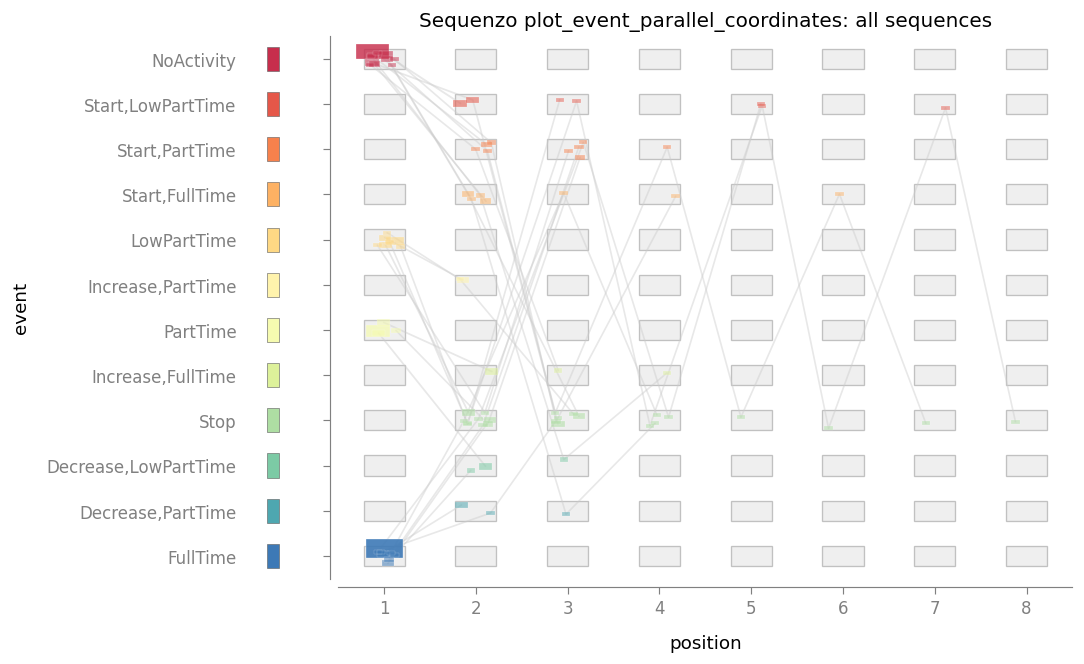

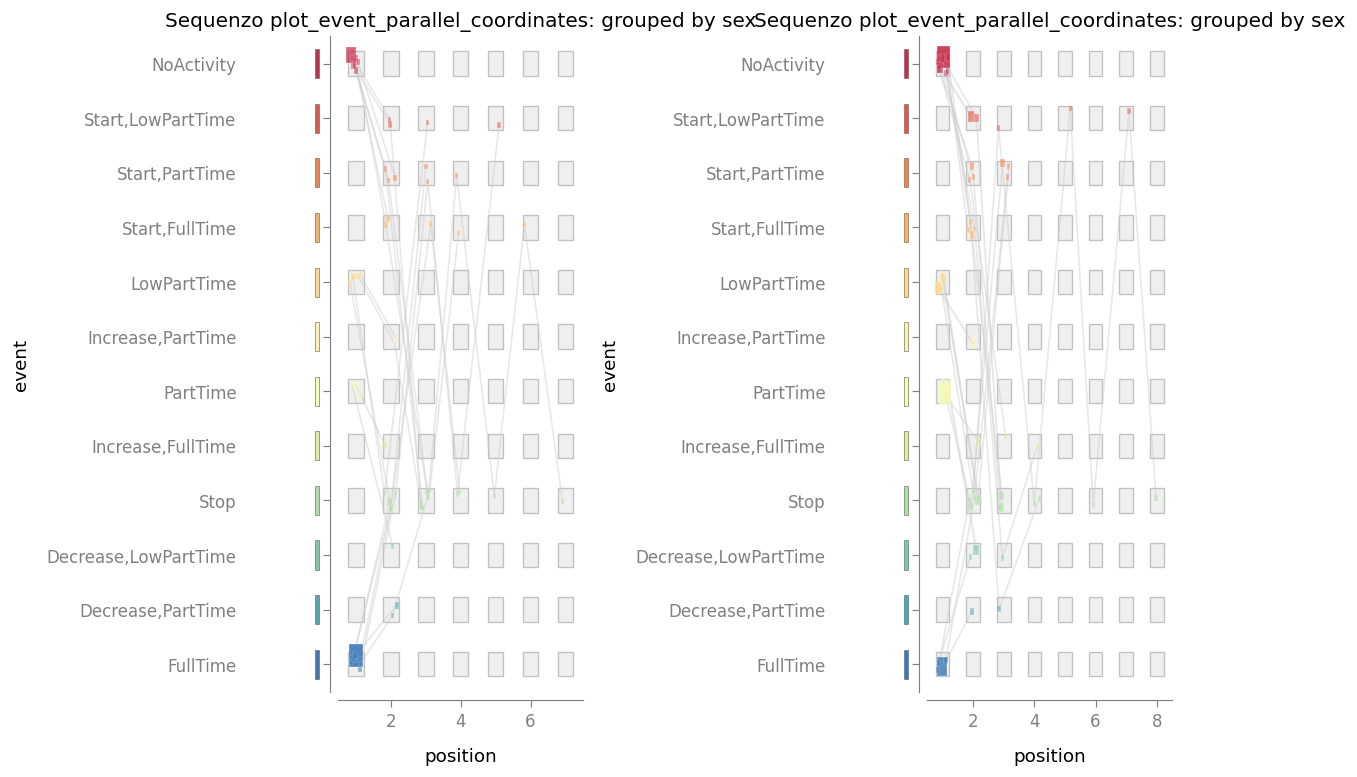

In [6]:
fig = plot_event_parallel_coordinates(
    eseq,
    title="Sequenzo plot_event_parallel_coordinates: all sequences",
    x_label="Position",
    y_label="Event",
    figsize=(11, 6),
    save_as="outputs/event_parallel_all",
    dpi=300,
    show=True,
)

fig = plot_event_parallel_coordinates(
    eseq,
    group_labels=group,
    title="Sequenzo plot_event_parallel_coordinates: grouped by sex",
    x_label="Position",
    y_label="Event",
    figsize=(12, 7),
    save_as="outputs/event_parallel_by_sex",
    dpi=300,
    show=True,
)


## Part E — Visualization B: `plot_subsequence_frequencies`

Equivalent to TraMineR `plot.subseqelist`. Below: support, then counts.

This function also supports the unified common parameters (`save_as`, `dpi`, `show`, `xlab`, `ylab`).


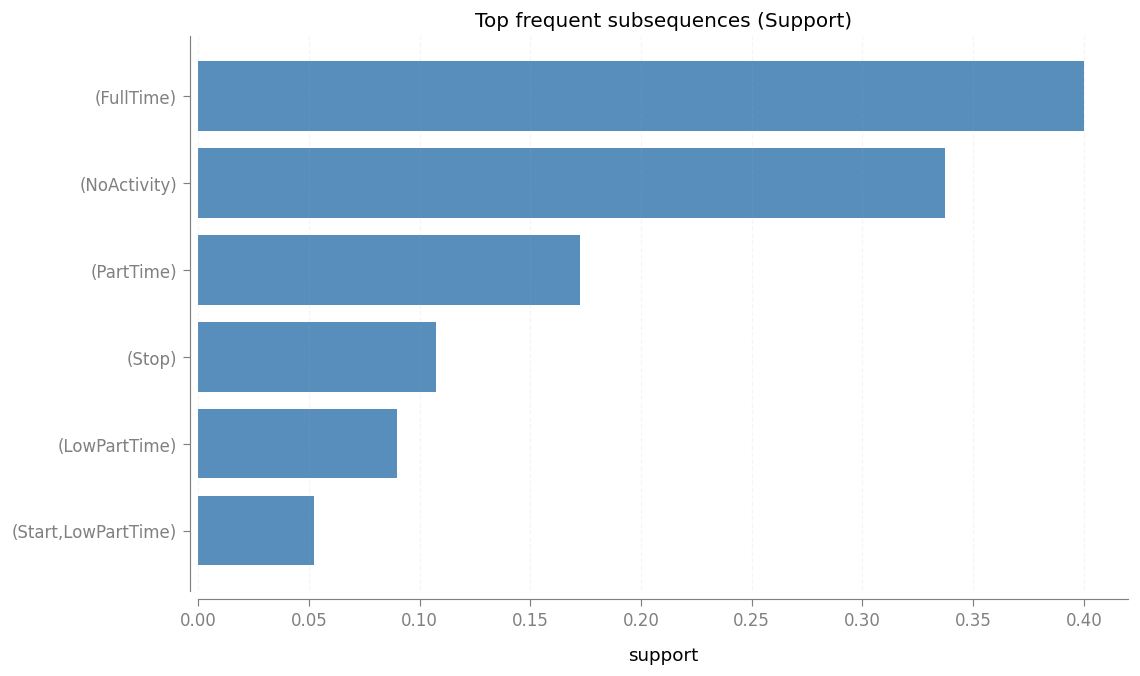

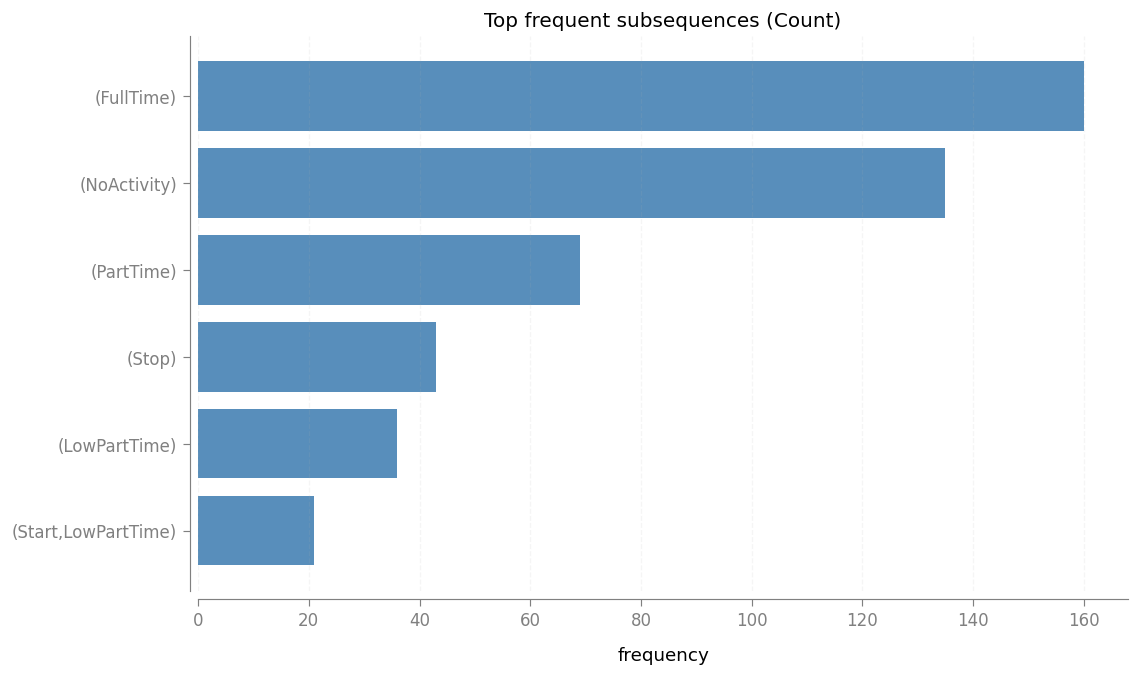

In [7]:
fig = plot_subsequence_frequencies(
    fsub[:12],
    title="Top frequent subsequences (Support)",
    x_label="Support",
    y_label="Subsequence",
    save_as="outputs/subsequence_support_top12",
    dpi=300,
    show=True,
)

fig = plot_subsequence_frequencies(
    fsub[:12],
    frequency_values=fsub.data["Count"].values[:12],
    title="Top frequent subsequences (Count)",
    x_label="Count",
    y_label="Subsequence",
    save_as="outputs/subsequence_count_top12",
    dpi=300,
    show=True,
)


## Part F — Visualization C: `plot_subsequence_group_contrasts`

Equivalent to TraMineR `plot.subseqelistchisq`.

- `plot_type="freq"` — group-specific frequencies  
- `plot_type="resid"` — Pearson residuals

This function supports the same common parameters (`save_as`, `dpi`, `show`, `xlab`, `ylab`).


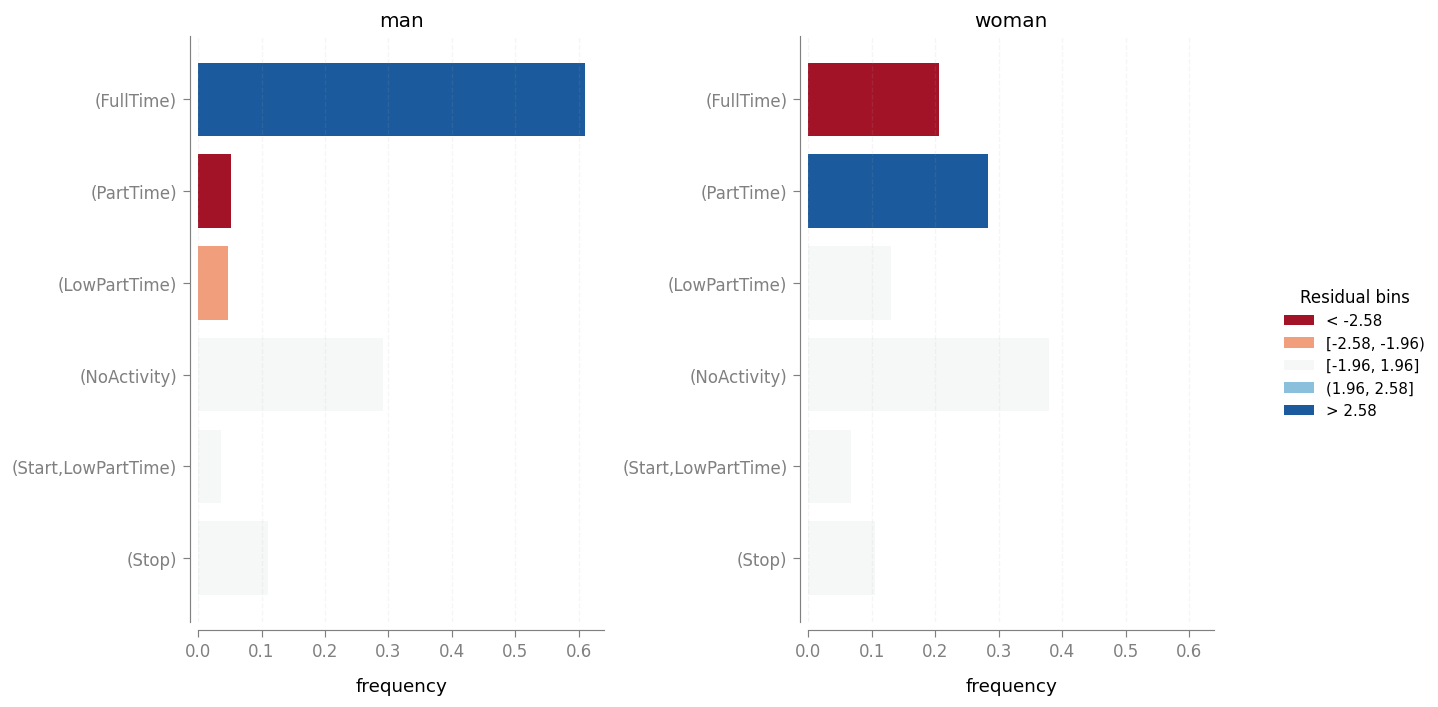

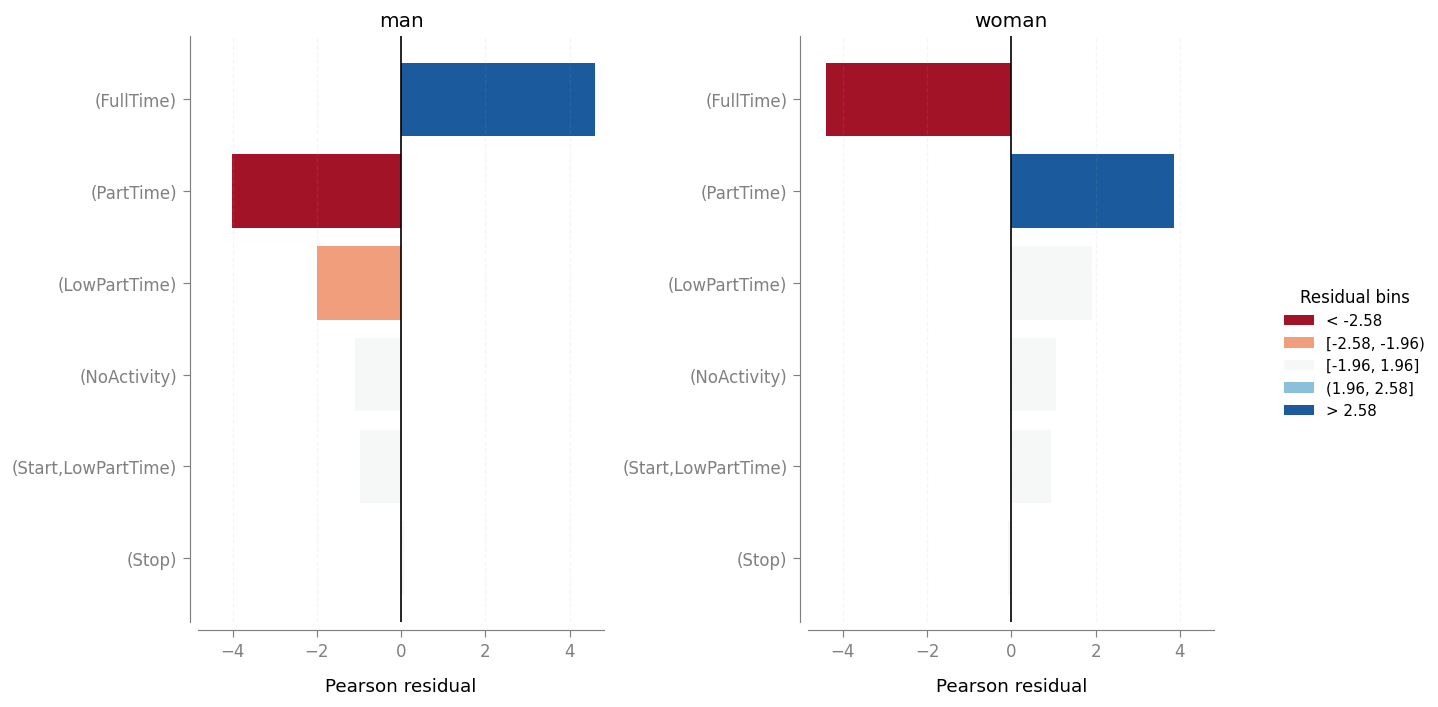

In [8]:
if len(discr) > 0:
    fig = plot_subsequence_group_contrasts(
        discr[:10],
        plot_type="freq",
        figsize=(12, 6),
        x_label="Frequency",
        y_label="Subsequence",
        save_as="outputs/subsequence_group_contrasts_freq",
        dpi=300,
        show=True,
    )

    fig = plot_subsequence_group_contrasts(
        discr[:10],
        plot_type="resid",
        figsize=(12, 6),
        x_label="Pearson residual",
        y_label="Subsequence",
        save_as="outputs/subsequence_group_contrasts_resid",
        dpi=300,
        show=True,
    )
else:
    print("No discriminating subsequences for current support threshold.")


## Part G — Visualization D: `plot_event_dynamics` (`survival` and `hazard`)

Here **`eseq` is still the object built in Part B** from **STS + the transition matrix** (times follow the state-sequence construction). That lets us demo `plot_event_dynamics` on the same pipeline as above.

The R Quarto file builds a **different** event-sequence object for section 7 with `seqecreate(actcal.tse)` — true calendar events from the long table. To match that figure numerically, read `actcal_tse.csv` and call `EventSequenceData.from_tse` on columns `id`, `time`, `event`, then pass that list to `plot_event_dynamics`.

This function also supports the unified common parameters (`save_as`, `dpi`, `show`, `xlab`, `ylab`).


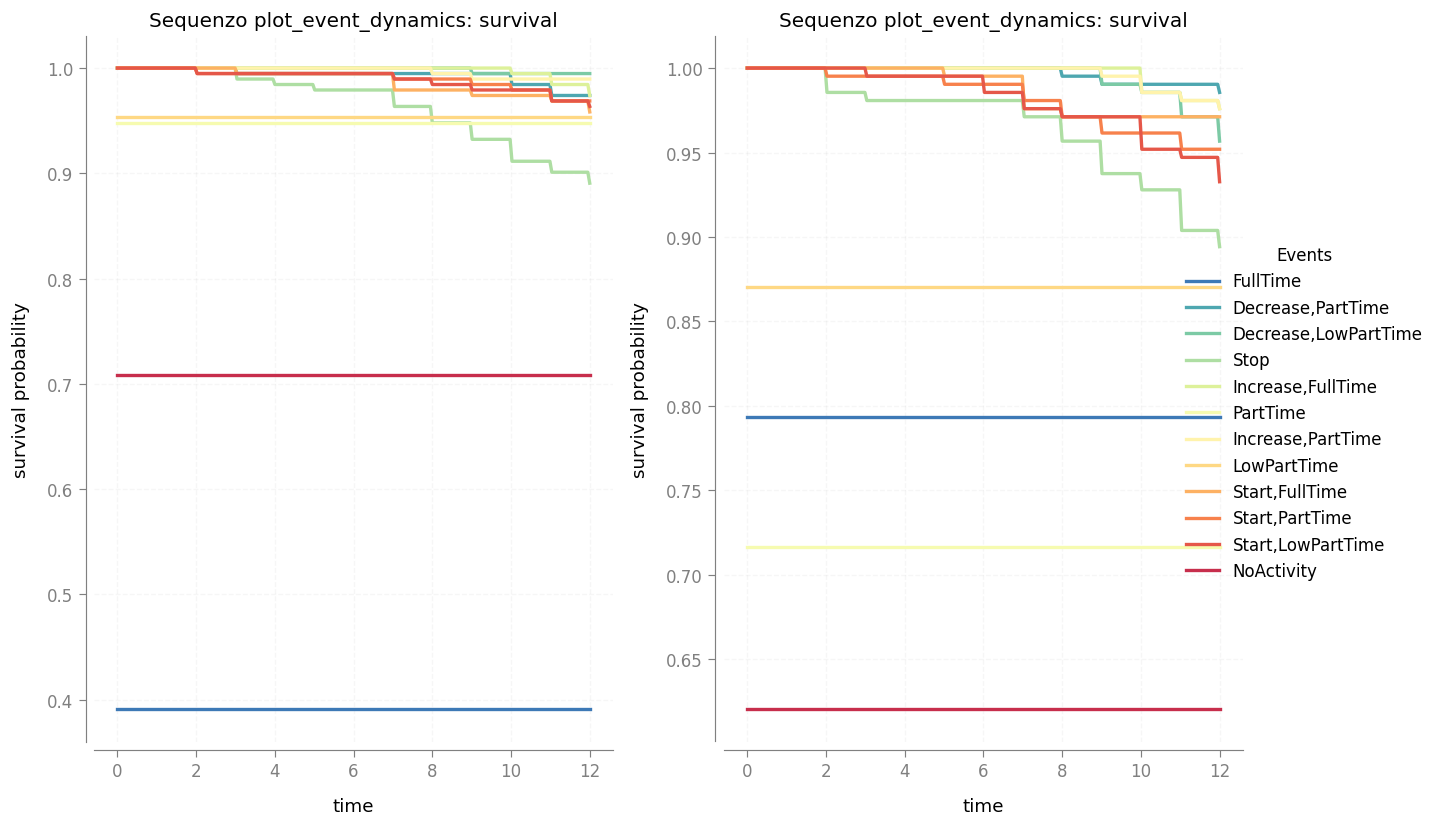

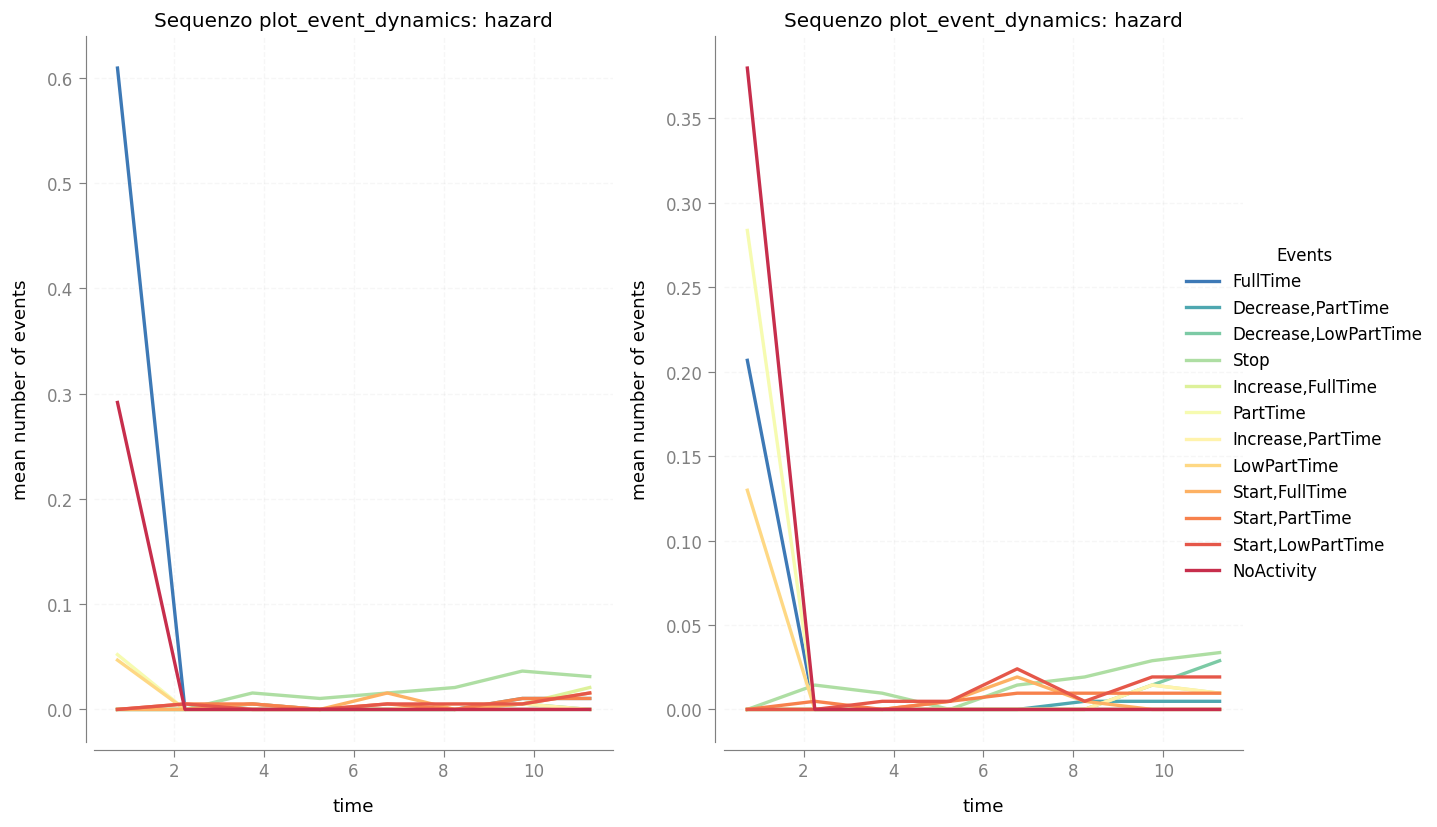

In [9]:
fig = plot_event_dynamics(
    eseq,
    group_labels=group,
    curve_type="survival",
    title="Sequenzo plot_event_dynamics: survival",
    x_label="Time",
    y_label="Survival probability",
    figsize=(12, 7),
    save_as="outputs/event_dynamics_survival",
    dpi=300,
    show=True,
)

fig = plot_event_dynamics(
    eseq,
    group_labels=group,
    curve_type="hazard",
    num_bins=8,
    title="Sequenzo plot_event_dynamics: hazard",
    x_label="Time",
    y_label="Mean number of events",
    figsize=(12, 7),
    save_as="outputs/event_dynamics_hazard",
    dpi=300,
    show=True,
)


## Closing note

Keep subset sizes and figure geometry similar to the R run when you compare plots side by side. Re-run this notebook after changing `nrows` or filters so printed tables and figures stay consistent.
